# **Loan Default Risk Predictor - Capstone Project**

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import  classification_report, confusion_matrix, auc, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset: dataset was sourced from kaggle (https://www.kaggle.com/datasets/laotse/credit-risk-dataset)
df = pd.read_csv('credit_risk_dataset.csv')
# Viewing the first five rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Viewing the last five rows
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


**Feature Name -	            Description**

person_age -	                   Age

person_income -	            Annual Income

person_home_ownership -	    Home ownership

person_emp_length -	        Employment length (in years)

loan_intent -	                Loan intent

loan_grade -	                Loan grade

loan_amnt -	                Loan amount

loan_int_rate -	            Interest rate

loan_status -	                Loan status (0 is non default 1 is default)

loan_percent_income -	        Percent income

cb_person_default_on_file -	Historical default

cb_preson_cred_hist_length -	Credit history length

## **Exploratory Data Analysis (EDA)**

In [4]:
# Checking the number of rows and columns
df.shape

(32581, 12)

In [5]:
# Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(165)

In [7]:
# Removing duplicate records
df.drop_duplicates(inplace=True)
# New data size
df.shape

(32416, 12)

In [8]:
# Checking for missing values
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
# Handling missing values
print("Mode and Median of the variables")
print("="*40)
print("person_emp_length")
print(f"Mode: {df['person_emp_length'].mode()[0]}")
print(f"Median: {df['person_emp_length'].median()}")
print("="*40)
print("loan_int_rate")
print(f"Mode: {df['loan_int_rate'].mode()[0]}")
print(f"Median: {df['loan_int_rate'].median()}")

Mode and Median of the variables
person_emp_length
Mode: 0.0
Median: 4.0
loan_int_rate
Mode: 7.51
Median: 10.99


**Comment:**  
* `person_emp_length` is the person employment history. To be more conservative, the null values will be replaced with mode, which is 0 year.
* `loan_int_rate` is the loan income rate. To be more conservative, the null values will be replaced with the median, 10.99.

In [10]:
# Filling the null values
df['person_emp_length'].fillna(df['person_emp_length'].mode()[0], inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Rechecking for missing values
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [11]:
# Summary statistics of numeric variables
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.659427,9593.845632,11.014662,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.162406,6322.730241,3.083050,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**Comment**

The large gap between the maximum values and 75th percentile of the `person_age`, `person_emp_length`, and `person_income` variables is indicative of outliers.

These outliers will be removed.

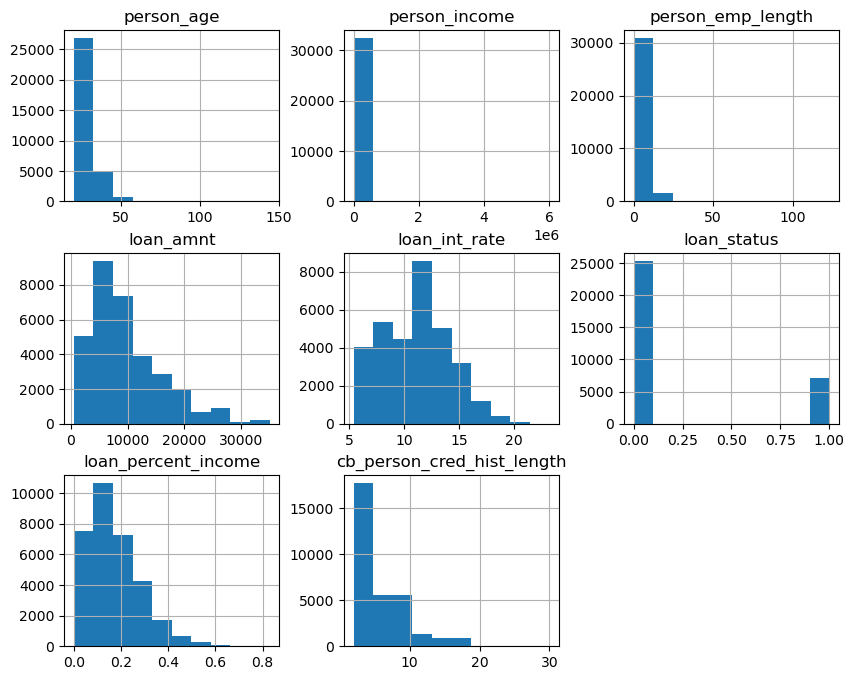

In [12]:
# Distribution of numeric variables
df.hist(figsize=(10,8))
plt.show()

**Comment**

* `person_age`: Most of the people were between 20 to 60 years. People aged `> 100` will be droped.
* `person_emp_length`: Most of the people had less than 40 years of employment. People with employment `> 60 years` will be dropped.
* `person_income`: People with income `> 4 million` will be dropped

In [13]:
# Removing outliers
clean_df = df[df['person_age']<=100]
clean_df = clean_df[clean_df['person_emp_length']<=60]
clean_df = clean_df[clean_df['person_income']<=4e6]
clean_df = clean_df.reset_index(drop=True)

# Data size of the cleaned data
print(clean_df.shape)

# New summary statistics of numerical variables
clean_df.describe()

(32409, 12)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.651949,9592.486655,11.014512,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,4.057459,6320.885127,3.083104,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


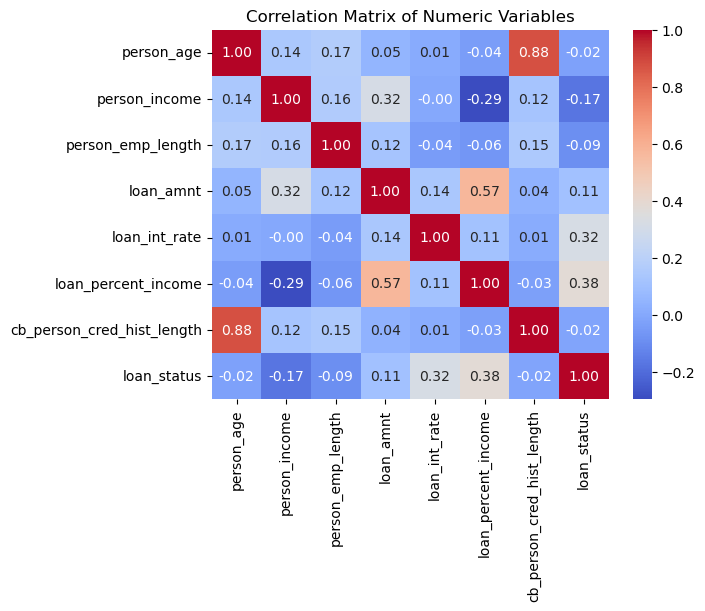

In [14]:
# Assessing  the relationship between the numeric variables
num_var = clean_df[['person_age','person_income','person_emp_length','loan_amnt',
                    'loan_int_rate','loan_percent_income','cb_person_cred_hist_length','loan_status']]

corr = num_var.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

**Comment** 

* There is an inverse relationship between loan_status and `person_income`, `person_emp_length`, and `person_age`, implying that the larger these variebles, the less likely the person will default.
* There is a positive correlation between loan_status and `loan_percent_income`, `loan_int_rate`, and `loan_amnt`, which implies that the larger these variebles, the more likely the person will default.

## **Feature Engineering & Data Preprocessing**

In [15]:
# Encoding features
cat_feat = clean_df[['person_home_ownership', 'loan_intent', 'loan_grade','cb_person_default_on_file']]
num_feat = clean_df[['person_age','person_income','person_emp_length','loan_amnt',
                    'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']]

one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
min_max = MinMaxScaler()

# Encoding categorical features
cat_feat_scaled = pd.DataFrame(one_hot.fit_transform(cat_feat),columns=one_hot.get_feature_names_out(cat_feat.columns))
# Encoding numerical features
num_feat_scaled = pd.DataFrame(min_max.fit_transform(num_feat),columns=num_feat.columns)
x = pd.concat([num_feat_scaled,cat_feat_scaled],axis=1)

# Assigning target variable
y = clean_df['loan_status']

# The encoded dataframe
encoded_df = pd.concat([x,y],axis=1)

# Viweing the encoded dataframe
print(encoded_df.shape)
encoded_df.head()

(32409, 27)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_status
0,0.013514,0.002751,0.121951,0.014493,0.321348,0.120482,0.000000,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,0.067568,0.002751,0.024390,0.144928,0.418539,0.686747,0.035714,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,0.040541,0.030209,0.097561,1.000000,0.551124,0.638554,0.000000,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,0.054054,0.024757,0.195122,1.000000,0.497191,0.662651,0.071429,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,0.013514,0.002898,0.048780,0.057971,0.096629,0.301205,0.000000,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


## **Building Model**

In [16]:
# Splitting dataset into training 70% and testing 30% sets

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.3)

# defining a function that trains a model and tests the model performance

def build_model(model, name='Default'):
    '''
    This function is used to train and test model performance 
    
    Input: model, defined classifer
    Output: classification report
    
    '''
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(name, '\n',classification_report(y_test, y_pred))

In [17]:
#Logistic Regression
log = LogisticRegression(random_state=42,max_iter=1000)
build_model(log, 'Logistic Regression')

#KNN
knn = KNeighborsClassifier(n_neighbors=21)
build_model(knn, name='KNN')

# Decision tree
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
build_model(tree, 'Decision Tree')

# Random Forest
rf = RandomForestClassifier(random_state=42,n_estimators=100)
build_model(rf, 'Random Forest')

#XGB
xgb = XGBClassifier(objective="binary:logistic", random_state=42,learning_rate=0.1,n_estimators=100) 
build_model(xgb, 'XGBoost')

Logistic Regression 
               precision    recall  f1-score   support

           0       0.88      0.95      0.92      7605
           1       0.76      0.54      0.63      2118

    accuracy                           0.86      9723
   macro avg       0.82      0.75      0.77      9723
weighted avg       0.85      0.86      0.85      9723

KNN 
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      7605
           1       0.89      0.57      0.70      2118

    accuracy                           0.89      9723
   macro avg       0.89      0.78      0.81      9723
weighted avg       0.89      0.89      0.88      9723

Decision Tree 
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      7605
           1       0.94      0.71      0.81      2118

    accuracy                           0.93      9723
   macro avg       0.93      0.85      0.88      9723
weighted avg       0.93      0

**Comment**

* All models demonstrated an overall good performance
* The `Logistic Regression` model had the lowest accuracy score of `86%`, followed by `KNN` with `89%`
* `Decision Tree`, `Random Forest`, and `XGBoost` had the same accuracy scores `93%`

The `AUROC` curve below illustrates each models' ability to correctly predict loan defaulters and non-defaulters

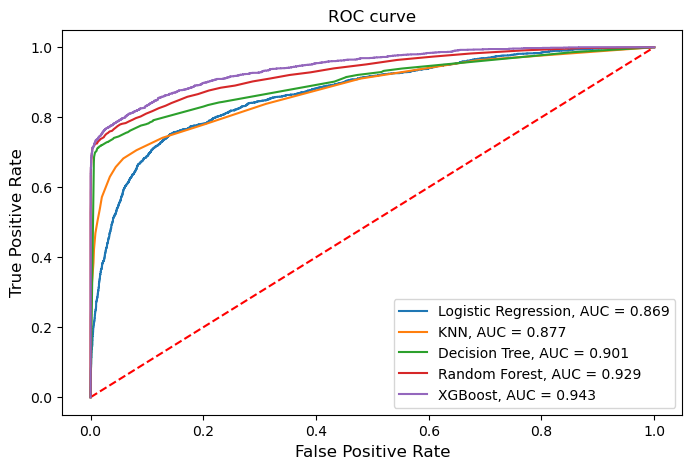

In [18]:
#AUROC
fig = plt.figure(figsize=(8,5))
plt.plot([0, 1], [0, 1],'r--')


#Logistic Regression
preds_proba_log = log.predict_proba(x_test)
probslog = preds_proba_log[:, 1]
fpr, tpr, thresh = roc_curve(y_test, probslog)
auclog = roc_auc_score(y_test, probslog)
plt.plot(fpr, tpr, label=f'Logistic Regression, AUC = {str(round(auclog,3))}')

#KNN
preds_proba_knn = knn.predict_proba(x_test)
probsknn = preds_proba_knn[:, 1]
fpr, tpr, thresh = roc_curve(y_test, probsknn)
aucknn = roc_auc_score(y_test, probsknn)
plt.plot(fpr, tpr, label=f'KNN, AUC = {str(round(aucknn,3))}')

#Decision Tree
preds_proba_tree = tree.predict_proba(x_test)
probstree = preds_proba_tree[:, 1]
fpr, tpr, thresh = roc_curve(y_test, probstree)
auctree = roc_auc_score(y_test, probstree)
plt.plot(fpr, tpr, label=f'Decision Tree, AUC = {str(round(auctree,3))}')

#Random Forest
preds_proba_rf = rf.predict_proba(x_test)
probsrf = preds_proba_rf[:, 1]
fpr, tpr, thresh = roc_curve(y_test, probsrf)
aucrf = roc_auc_score(y_test, probsrf)
plt.plot(fpr, tpr, label=f'Random Forest, AUC = {str(round(aucrf,3))}')

#XGBoost
preds_proba_xgb = xgb.predict_proba(x_test)
probsxgb = preds_proba_xgb[:, 1]
fpr, tpr, thresh = roc_curve(y_test, probsxgb)
aucxgb = roc_auc_score(y_test, probsxgb)
plt.plot(fpr, tpr, label=f'XGBoost, AUC = {str(round(aucxgb,3))}')

plt.ylabel("True Positive Rate", fontsize=12)
plt.xlabel("False Positive Rate", fontsize=12)
plt.title("ROC curve")
plt.rcParams['axes.titlesize'] = 16
plt.legend()
plt.show()

**Comment**

* The **XGBoost** model demonstrated the best performance with AUC score of `0.94`
* The **Loan Default Risk Predictor** will therefore be built with the trained XGBoost

## **Confusion Matrix**

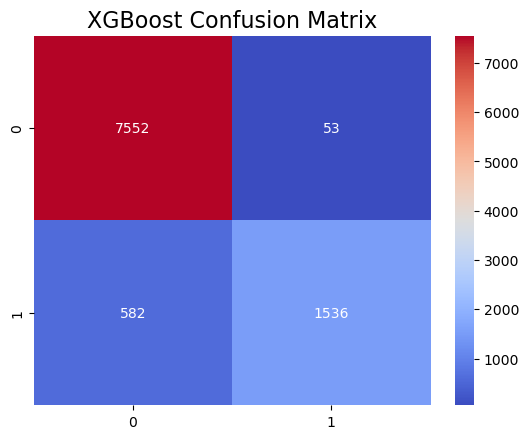

In [19]:
# Confusion Matrix

xgb_y_pred = xgb.predict(x_test)
xgb_cm = confusion_matrix(y_test,xgb_y_pred)
sns.heatmap(xgb_cm, annot=True,fmt='d', cmap='coolwarm')

plt.title('XGBoost Confusion Matrix',fontsize=16)
plt.show()

### **Key Factors (Feature Importance)**

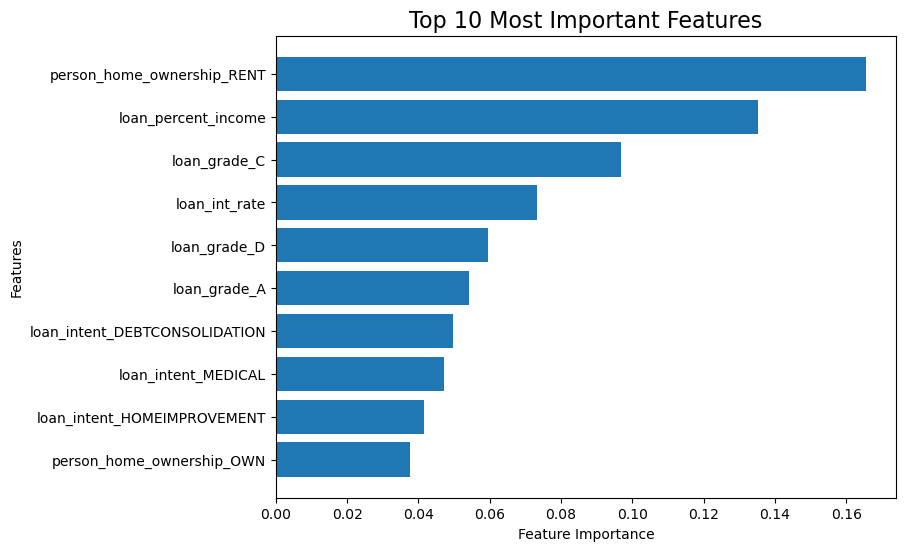

In [20]:
# Extract feature importance

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb.feature_importances_
})

# Sorting the feature by importance
importance = (
    importance
    .sort_values(by='Importance', ascending=False)
    .head(10)
    .sort_values(by='Importance')
)

plt.figure(figsize=(8,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features')
plt.show()

**Comment**

* The bar chart above shows the `top ten factors` that determine whether a person defaults a loan or not.
* The top predictor of loan default is `renting a home`, followed by the `percent income` (the percentage of the loan to the person's income).

## **Risk Score**

In [27]:
# Determing the risk of each person being a loan defauter (using test dataset)

risk_score = xgb.predict_proba(x_test)[:,1]
risk = pd.DataFrame({
    'Actual': y_test,
    'Risk Score (%)': risk_score * 100
})

print('Risk Score Table')
risk.head()

Risk Score Table


,Actual,Risk Score (%)
30548,0,4.788802
15819,0,3.446941
14105,0,0.832867
28703,0,1.986759
15939,0,22.190281


In [23]:
risk.tail()

,Actual,Risk Score (%)
11299,0,14.360039
15952,1,98.584358
16553,0,8.447843
3437,1,87.990059
7247,0,10.278936


**Comment**

* The dataframes above show the percentage risk of each individual defaulting (as predicted by the XGBoost Model)

## **Conclusion and Recommendation**

* Among the five models evaluated, XGBoost achieved the best overall performance, making it the most suitable model for credit risk prediction.
  
* The model also identified the key factors influencing loan default and generated risk scores that can support more informed lending decisions.

* The developed XGBoost model can be adopted by microfinance banks, digital lenders, POS agents, and other lending institutions as a decision-support tool to assess borrower risk before loan approval.

* Its use can improve the speed, consistency, and accuracy of credit decisions while reducing loan default rates.